# STEP 1 — Import libraries

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 75.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


# STEP 2 — Load the dataset

In [3]:
df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (45211, 17)


# Display dataset

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Dataset information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# Column names

In [6]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Columns:
1 : age
2 : job
3 : marital
4 : education
5 : default
6 : balance
7 : housing
8 : loan
9 : contact
10 : day
11 : month
12 : duration
13 : campaign
14 : pdays
15 : previous
16 : poutcome
17 : y


# STEP 3 — Verify assignment requirements

In [7]:
number_of_instances = df.shape[0]
number_of_features = df.shape[1] - 1

print("Number of instances:", number_of_instances)
print("Number of input features:", number_of_features)

if number_of_instances >= 500 and number_of_features >= 12:
    print("\nDataset satisfies the assignment requirements.")
else:
    print("\nDataset does NOT satisfy the assignment requirements.")

Number of instances: 45211
Number of input features: 16

Dataset satisfies the assignment requirements.


# STEP 4 — Check missing values

In [8]:
missing_values = df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", missing_values.sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing values: 0


# STEP 5 — Check duplicate records

In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# STEP 6 — Examine the target variable

y

yes = customer subscribed

no  = customer did not subscribe

In [10]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [11]:
#percentage:
print(
    df["y"].value_counts(normalize=True) * 100
)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


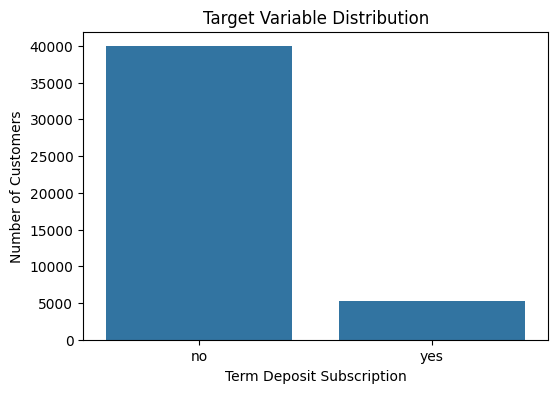

In [12]:
#Visualize it:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Target Variable Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")

plt.show()

# STEP 7 — Separate features and target

In [13]:
X = df.drop("y", axis=1)
y = df["y"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (45211, 16)
Target shape: (45211,)


# STEP 8 — Convert target yes/no to 1/0

In [14]:
#Convert target yes/no to 1/0
y = y.map({
    "no": 0,
    "yes": 1
})

print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


# STEP 9 — Identify numerical and categorical columns

In [15]:
#Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# STEP 10 — Train/Test split

We'll use 80% training and 20% testing.

Most importantly, we'll use stratify=y so that the target distribution is maintained.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 16)
Testing data: (9043, 16)


# STEP 11 — Create preprocessing pipeline

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# STEP 12 — Create the five required models

We'll create a separate pipeline for each model.

**12.1** **Logistic** **Regression**

In [18]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**12.2 Decision Tree**

In [19]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


**12.3 kNN**

In [20]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

knn_model.fit(X_train, y_train)

print("kNN trained successfully.")

kNN trained successfully.


**12.4 Gaussian Naive Bayes**

There is one special issue here.

GaussianNB requires numerical input, while our dataset contains categorical variables.

We'll therefore create a preprocessing pipeline that converts categorical variables to numerical one-hot encoded values.

In [21]:
nb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [22]:
naive_bayes_model = Pipeline(
    steps=[
        ("preprocessor", nb_preprocessor),
        (
            "classifier",
            GaussianNB()
        )
    ]
)

naive_bayes_model.fit(X_train, y_train)

print("Naive Bayes trained successfully.")

Naive Bayes trained successfully.


**12.5 Random Forest**

In [23]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


# STEP 13 — Make predictions

In [24]:
# Logistic Regression
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Decision Tree
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# kNN
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Naive Bayes
y_pred_nb = naive_bayes_model.predict(X_test)
y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


# STEP 14 — Create evaluation function
The assignment requires these six metrics for every model:

Accuracy

AUC

Precision

Recall

F1

MCC

In [25]:
def evaluate_model(y_true, y_pred, y_prob):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }

# STEP 15 — Evaluate all five models

In [26]:
results = {}

results["Logistic Regression"] = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

results["Decision Tree"] = evaluate_model(
    y_test,
    y_pred_dt,
    y_prob_dt
)

results["kNN"] = evaluate_model(
    y_test,
    y_pred_knn,
    y_prob_knn
)

results["Naive Bayes"] = evaluate_model(
    y_test,
    y_pred_nb,
    y_prob_nb
)

results["Random Forest"] = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf
)

print("All models evaluated.")

All models evaluated.


# STEP 16 — Required comparison table

In [27]:
results_df = pd.DataFrame(results).T

results_df = results_df[
    [
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
]

results_df = results_df.reset_index()

# Rename the first column
results_df = results_df.rename(
    columns={"index": "ML Model Name"}
)

results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.901250,0.905574,0.644483,0.347826,0.451811,0.426058
1,Decision Tree,0.874599,0.701457,0.464880,0.475425,0.470093,0.399021
2,kNN,0.896163,0.827721,0.599002,0.340265,0.433996,0.400128
3,Naive Bayes,0.854805,0.810095,0.405904,0.519849,0.455864,0.377358
4,Random Forest,0.904456,0.926286,0.650621,0.396030,0.492362,0.459724


In [28]:
results_rounded = results_df.round(4)

results_rounded

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9012,0.9056,0.6445,0.3478,0.4518,0.4261
1,Decision Tree,0.8746,0.7015,0.4649,0.4754,0.4701,0.3990
2,kNN,0.8962,0.8277,0.5990,0.3403,0.4340,0.4001
3,Naive Bayes,0.8548,0.8101,0.4059,0.5198,0.4559,0.3774
4,Random Forest,0.9045,0.9263,0.6506,0.3960,0.4924,0.4597


# STEP 17 — Find the best model

In [29]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

results_df["Average Score"] = results_df[metric_columns].mean(axis=1)

ranking = results_df.sort_values(
    "Average Score",
    ascending=False
)

ranking

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,Average Score
4,Random Forest,0.904456,0.926286,0.650621,0.396030,0.492362,0.459724,0.638247
0,Logistic Regression,0.901250,0.905574,0.644483,0.347826,0.451811,0.426058,0.612834
2,kNN,0.896163,0.827721,0.599002,0.340265,0.433996,0.400128,0.582879
3,Naive Bayes,0.854805,0.810095,0.405904,0.519849,0.455864,0.377358,0.570646
1,Decision Tree,0.874599,0.701457,0.464880,0.475425,0.470093,0.399021,0.564246


In [30]:
overall_winner = ranking.iloc[0]["ML Model Name"]

print("Overall Winner:", overall_winner)

Overall Winner: Random Forest


# STEP 18 — Generate classification reports

In [31]:
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "kNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

for model_name, predictions in model_predictions.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["No", "Yes"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


Decision Tree
              precision    recall  f1-score   support

          No       0.93      0.93      0.93      7985
         Yes       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043


kNN
              precision    recall  f1-score   support

          No       0.92      0.97      0.94      7985
         Yes       0.60      0.34      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90

# STEP 19 — Confusion matrix for every model

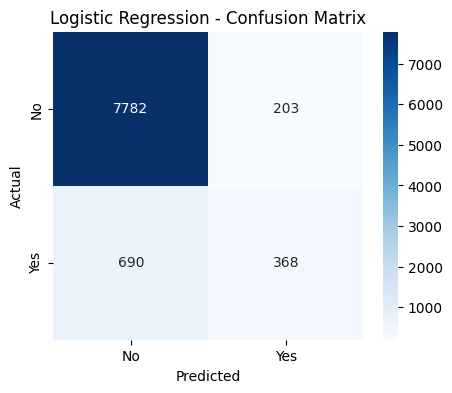

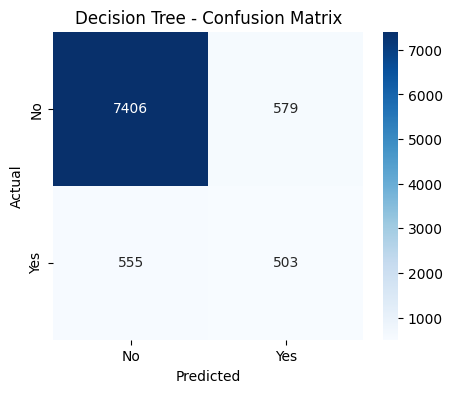

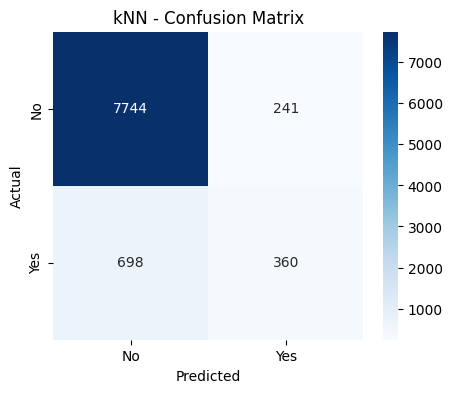

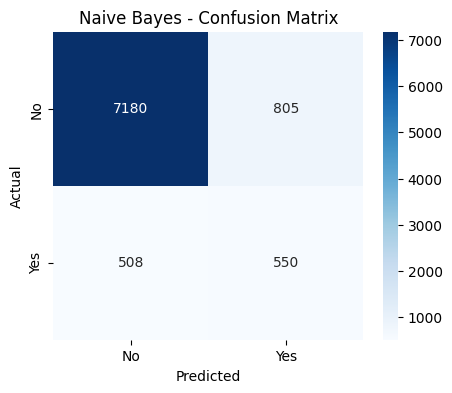

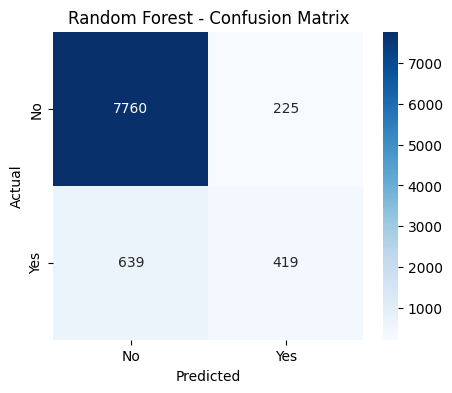

In [32]:
for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(
        model_name + " - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# STEP 20 — Save the five models

In [33]:
os.makedirs("model", exist_ok=True)

print("model folder created.")

model folder created.


In [34]:
joblib.dump(
    logistic_model,
    "model/logistic_regression.pkl"
)

joblib.dump(
    decision_tree_model,
    "model/decision_tree.pkl"
)

joblib.dump(
    knn_model,
    "model/knn.pkl"
)

joblib.dump(
    naive_bayes_model,
    "model/naive_bayes.pkl"
)

joblib.dump(
    random_forest_model,
    "model/random_forest.pkl"
)

print("All five models saved successfully.")

All five models saved successfully.


# STEP 21 — Save the feature column information

In [35]:
joblib.dump(
    X.columns.tolist(),
    "model/feature_columns.pkl"
)

print("Feature column information saved.")

Feature column information saved.


# STEP 22 — Create test_data.csv

In [36]:
test_data = X_test.copy()

test_data["y"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully.")
print("Shape:", test_data.shape)

test_data.csv created successfully.
Shape: (9043, 17)


In [37]:
test_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown,0
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown,0
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown,0
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,153,4,-1,0,unknown,0
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,61,1,-1,0,unknown,0


# STEP 23 — Save the results

In [38]:
results_df.round(4).to_csv(
    "model_results.csv"
)

print("model_results.csv saved successfully.")

model_results.csv saved successfully.


# STEP 24 — Verify the project files

In [39]:
print("Project files:")

for root, dirs, files in os.walk("."):
    level = root.replace(".", "").count(os.sep)
    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    for file in files:
        print(indent + "    " + file)

Project files:
./
    test_data.csv
    model_results.csv
    bank-full.csv
    .config/
        .last_survey_prompt.yaml
        hidden_gcloud_config_universe_descriptor_data_cache_configs.db
        .last_opt_in_prompt.yaml
        gce
        config_sentinel
        active_config
        default_configs.db
        .last_update_check.json
        configurations/
            config_default
        logs/
            2026.08.10/
                13.26.19.834999.log
                13.26.18.998373.log
                13.24.58.373513.log
                13.26.03.888211.log
                13.25.25.328016.log
                13.25.43.233148.log
    model/
        naive_bayes.pkl
        knn.pkl
        logistic_regression.pkl
        random_forest.pkl
        feature_columns.pkl
        decision_tree.pkl
    sample_data/
        anscombe.json
        README.md
        california_housing_test.csv
        california_housing_train.csv
        mnist_test.csv
        mnist_train_small.csv
